# Phase 2: Profiling & Discovery

Phase 1 gave me the lay of the land. Now I need to dig into the key fields, look for patterns, and figure out which threads are worth pulling on for Phase 3.

I'm excluding National Defence from here on - their procurement is structurally different (multi-billion shipbuilding, fighter jets) and would drown out every other pattern. I'm also filtering to rows with valid `reporting_period` formats only.

In [23]:
import os
import duckdb
import polars as pl
from dotenv import load_dotenv

load_dotenv(override=True)
dataset_path = os.getenv("LOCAL_DATASET_PATH")
con = duckdb.connect(database=":memory:")

con.execute("""
    CREATE TEMP TABLE contracts AS
    SELECT * FROM read_csv_auto(
        '{0}', delim=',', header=true, strict_mode=false, all_varchar=true, parallel=false
    )
""".format(dataset_path))

# Reusable view: excludes Defence, casts types, filters to valid reporting periods
con.execute("""
    CREATE TEMP VIEW data AS
    SELECT *,
        TRY_CAST(contract_value AS DOUBLE) AS val,
        TRY_CAST(original_value AS DOUBLE) AS orig_val,
        TRY_CAST(amendment_value AS DOUBLE) AS amend_val,
        LEFT(reporting_period, 9) AS fiscal_year,
        RIGHT(reporting_period, 2) AS quarter,
        CASE 
            WHEN reporting_period < '2019-2020' THEN 'Pre-2019'
            WHEN reporting_period >= '2019-2020' AND reporting_period < '2022-2023' THEN '2019-2022'
            WHEN reporting_period >= '2022-2023' THEN 'Post-2022'
        END AS era
    FROM contracts
    WHERE owner_org_title NOT LIKE 'National Defence%'
      AND reporting_period LIKE '____-____-Q_'
""")

print("Ready. Rows in analysis view:", con.sql("SELECT COUNT(*) FROM data").fetchone()[0])

Ready. Rows in analysis view: 814070


## Starting with the money

What does spending actually look like? Is it spread out or concentrated in a few big contracts?

In [24]:
# Contract value distribution (contracts only)
con.sql("""
    SELECT 
        CASE 
            WHEN val < 0 THEN 'Negative'
            WHEN val = 0 THEN '$0'
            WHEN val < 25000 THEN '< $25K'
            WHEN val < 100000 THEN '$25K-$100K'
            WHEN val < 1000000 THEN '$100K-$1M'
            WHEN val < 10000000 THEN '$1M-$10M'
            WHEN val >= 10000000 THEN '$10M+'
        END AS bucket,
        COUNT(*) AS contracts,
        ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct_count,
        ROUND(SUM(val)/1e9, 2) AS value_B,
        ROUND(SUM(val)*100.0/SUM(SUM(val)) OVER(), 1) AS pct_value
    FROM data
    WHERE instrument_type = 'C' AND val IS NOT NULL
    GROUP BY bucket
    ORDER BY MIN(val)
""").pl()

bucket,contracts,pct_count,value_B,pct_value
str,i64,f64,f64,f64
"""Negative""",5,0.0,-0.0,-0.0
"""$0""",329,0.1,0.0,0.0
"""< $25K""",284974,51.7,4.74,4.6
"""$25K-$100K""",178920,32.5,8.78,8.4
"""$100K-$1M""",76292,13.8,20.86,20.1
"""$1M-$10M""",9732,1.8,24.7,23.8
"""$10M+""",928,0.2,44.9,43.2


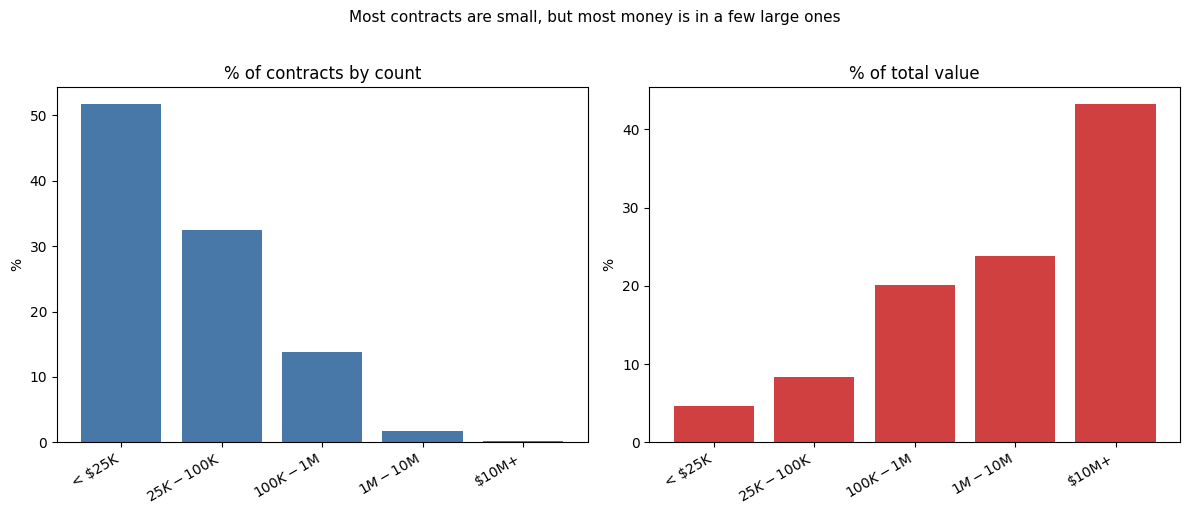

In [25]:
# Visualize: contract count vs value share by size bucket
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

val_dist = con.sql("""
    SELECT 
        CASE 
            WHEN val < 25000 THEN '< $25K'
            WHEN val < 100000 THEN '$25K-$100K'
            WHEN val < 1000000 THEN '$100K-$1M'
            WHEN val < 10000000 THEN '$1M-$10M'
            WHEN val >= 10000000 THEN '$10M+'
        END AS bucket,
        ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct_count,
        ROUND(SUM(val)*100.0/SUM(SUM(val)) OVER(), 1) AS pct_value
    FROM data WHERE instrument_type='C' AND val > 0
    GROUP BY bucket ORDER BY MIN(val)
""").pl()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
buckets = val_dist["bucket"].to_list()
x = range(len(buckets))

axes[0].bar(x, val_dist["pct_count"].to_list(), color='#4878A8')
axes[0].set_title("% of contracts by count")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(buckets, rotation=30, ha='right')
axes[0].set_ylabel("%")

axes[1].bar(x, val_dist["pct_value"].to_list(), color='#D04040')
axes[1].set_title("% of total value")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(buckets, rotation=30, ha='right')
axes[1].set_ylabel("%")

plt.suptitle("Most contracts are small, but most money is in a few large ones", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

Heavily skewed. Most contracts are small but most *dollars* are in a handful of large ones. Good to know, but not actionable on its own. What I really want to know is *how* these contracts are awarded.

## How competitive is the process?

The `solicitation_procedure` field tells me whether a contract was competed or sole-sourced. But this field was only mandatory after 2019, so I need to compare eras carefully.

In [26]:
# Solicitation procedure breakdown by era (contracts only)
con.sql("""
    SELECT era, solicitation_procedure,
        COUNT(*) AS cnt,
        ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(PARTITION BY era), 1) AS pct
    FROM data
    WHERE instrument_type = 'C' AND era IS NOT NULL
    GROUP BY era, solicitation_procedure
    ORDER BY era, cnt DESC
""").pl()

era,solicitation_procedure,cnt,pct
str,str,i64,f64
"""2019-2022""","""TC""",60016,41.3
"""2019-2022""","""TN""",54328,37.4
"""2019-2022""","""OB""",26788,18.4
"""2019-2022""","""ST""",2981,2.1
"""2019-2022""","""AC""",1211,0.8
…,…,…,…
"""Pre-2019""","""TC""",59872,27.4
"""Pre-2019""","""TN""",40200,18.4
"""Pre-2019""","""OB""",25842,11.8


Non-competitive (TN) went from 18.5% pre-2019 to 41.5% post-2022. But pre-2019 has 41.5% *unknown* because the field wasn't mandatory. So the increase might just be better visibility, not worse behaviour.

The 2019-to-2022 vs post-2022 comparison is more honest: 37.4% to 41.5%. A real but modest increase.

That raises a question - *why* are contracts non-competitive? There's a `limited_tendering_reason` field that should explain.

In [27]:
# Limited tendering reason for non-competitive contracts, by era
con.sql("""
    SELECT era, limited_tendering_reason, COUNT(*) AS cnt,
        ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(PARTITION BY era), 1) AS pct
    FROM data
    WHERE instrument_type = 'C' AND solicitation_procedure = 'TN' AND era IS NOT NULL
    GROUP BY era, limited_tendering_reason
    ORDER BY era, cnt DESC
""").pl()

era,limited_tendering_reason,cnt,pct
str,str,i64,f64
"""2019-2022""","""85""",23179,42.7
"""2019-2022""","""00""",17612,32.4
"""2019-2022""","""71""",6716,12.4
"""2019-2022""","""87""",2560,4.7
"""2019-2022""",null,950,1.7
…,…,…,…
"""Pre-2019""","""24""",25,0.1
"""Pre-2019""","""25""",17,0.0
"""Pre-2019""","""71,85""",7,0.0


Interesting. Pre-2019, "85" (Low dollar-value) was the top reason at 51%. But code 85 was **discontinued in 2022**. Without a replacement, departments just started putting "00" (None). So the spike in "no reason given" isn't negligence - it's a policy gap where the most common justification was removed.

This is useful context but it's a policy design issue, not something I can make a clean recommendation from. I'll note it and move on.

The non-competitive rate is complex across eras. Rather than making it a standalone insight, I'll use it as supporting context. Let me look at something more clearly actionable.

## Does spending behaviour change by quarter?

Canada's fiscal year runs April to March. Q4 (Jan-Mar) is the last quarter before budgets reset. If departments rush to spend at year-end, that should show up here.

In [28]:
# Quarterly pattern - count, total value, and average value
con.sql("""
    SELECT quarter,
        COUNT(*) AS contracts,
        ROUND(SUM(val)/1e9, 2) AS total_B,
        ROUND(AVG(val), 0) AS avg_value
    FROM data
    WHERE instrument_type = 'C'
    GROUP BY quarter ORDER BY quarter
""").pl()

quarter,contracts,total_B,avg_value
str,i64,f64,f64
"""Q1""",125545,23.82,189701.0
"""Q2""",120994,20.36,168310.0
"""Q3""",136075,23.56,173164.0
"""Q4""",168591,36.22,214868.0


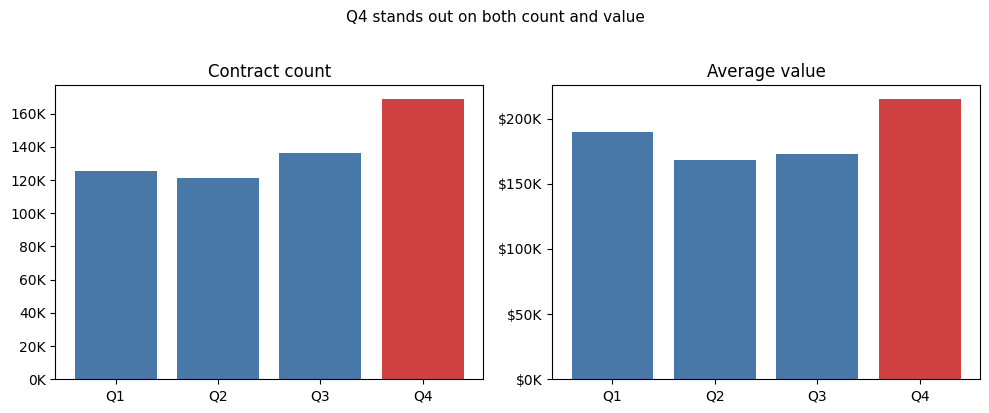

In [29]:
# Visualize quarterly pattern - the signal that led to Insight 1
q = con.sql("""
    SELECT quarter, COUNT(*) AS contracts, ROUND(AVG(val), 0) AS avg_value
    FROM data WHERE instrument_type='C'
    GROUP BY quarter ORDER BY quarter
""").pl()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#4878A8', '#4878A8', '#4878A8', '#D04040']

axes[0].bar(q["quarter"].to_list(), q["contracts"].to_list(), color=colors)
axes[0].set_title("Contract count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

axes[1].bar(q["quarter"].to_list(), q["avg_value"].to_list(), color=colors)
axes[1].set_title("Average value")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle("Q4 stands out on both count and value", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

There it is. Q4 has 34% more contracts and 50%+ more total value than the average of the other quarters. Classic year-end spending surge.

Two things to keep in mind:
1. The data dictionary says `reporting_period` is the quarter the contract was **reported to the public**, not when it was awarded. Some Q4 entries could be contracts awarded earlier but reported in Q4.
2. `reporting_period` only became mandatory after 2019-01-01. Pre-2019 data is missing ~22% of reporting periods, so the pre-2019 quarterly pattern is based on incomplete data. Post-2019 is more reliable.

That said, the pattern is too large and consistent to be explained by reporting lag or missing data alone.

This is worth a deep dive. I want to know if it holds in the post-2019 era (where reporting is mandatory), if specific departments drive it, and if the non-competitive rate is higher in Q4. **Marking for Phase 3.**

But the Q4 pattern makes me wonder about another mechanism for year-end spending: what if departments aren't just awarding *new* contracts in Q4, but also expanding *existing* ones?

## How do contracts change after they're awarded?

Amendments (instrument_type = 'A') modify existing contracts. Some are routine extensions. Others can multiply a contract's value many times over. How common are they?

In [30]:
# Amendment rate by era
con.sql("""
    SELECT era,
        COUNT(*) AS total_rows,
        SUM(CASE WHEN instrument_type='A' THEN 1 ELSE 0 END) AS amendments,
        ROUND(SUM(CASE WHEN instrument_type='A' THEN 1 ELSE 0 END)*100.0/COUNT(*), 1) AS amend_pct
    FROM data WHERE era IS NOT NULL
    GROUP BY era ORDER BY era
""").pl()

era,total_rows,amendments,amend_pct
str,i64,"decimal[38,0]",f64
"""2019-2022""",197472,48926,24.8
"""Post-2022""",252771,62335,24.7
"""Pre-2019""",363827,58920,16.2


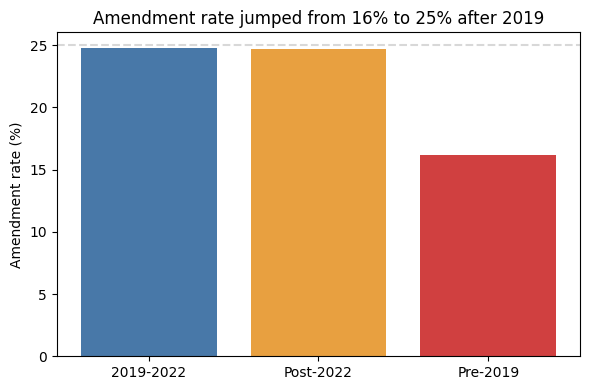

In [31]:
# Visualize amendment rate by era
amend_era = con.sql("""
    SELECT era,
        ROUND(SUM(CASE WHEN instrument_type='A' THEN 1 ELSE 0 END)*100.0/COUNT(*), 1) AS amend_pct
    FROM data WHERE era IS NOT NULL GROUP BY era ORDER BY era
""").pl()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(amend_era["era"].to_list(), amend_era["amend_pct"].to_list(), color=['#4878A8', '#E8A040', '#D04040'])
ax.set_ylabel("Amendment rate (%)")
ax.set_title("Amendment rate jumped from 16% to 25% after 2019")
ax.axhline(y=25, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

16% to 25% - that's a big jump. 1 in 4 rows is now an amendment. But that doesn't tell me if these are small adjustments or major scope changes. Let me check how much amended contracts actually grow.

In [32]:
# Quick look at extreme amendment growth - contracts that more than doubled
con.sql("""
    SELECT COUNT(*) AS total_amended,
        SUM(CASE WHEN growth_pct > 100 THEN 1 ELSE 0 END) AS doubled_plus,
        ROUND(SUM(CASE WHEN growth_pct > 100 THEN 1 ELSE 0 END)*100.0/COUNT(*), 1) AS doubled_pct,
        SUM(CASE WHEN growth_pct > 500 THEN 1 ELSE 0 END) AS grew_5x_plus
    FROM (
        SELECT procurement_id,
            (TRY_CAST(MAX(contract_value) AS DOUBLE) / 
             NULLIF(TRY_CAST(MIN(original_value) AS DOUBLE), 0) - 1) * 100 AS growth_pct
        FROM data
        WHERE procurement_id IS NOT NULL
        GROUP BY procurement_id
        HAVING COUNT(*) > 1 AND COUNT(DISTINCT instrument_type) > 1
    ) sub
    WHERE growth_pct IS NOT NULL
""").pl()

total_amended,doubled_plus,doubled_pct,grew_5x_plus
i64,"decimal[38,0]",f64,"decimal[38,0]"
69677,16833,24.2,1807


In [33]:
# Do amendments differ by commodity type?
con.sql("""
    SELECT commodity_type,
        COUNT(*) AS total,
        SUM(CASE WHEN instrument_type='A' THEN 1 ELSE 0 END) AS amendments,
        ROUND(SUM(CASE WHEN instrument_type='A' THEN 1 ELSE 0 END)*100.0/COUNT(*), 1) AS amend_pct
    FROM data
    WHERE reporting_period >= '2019-2020' AND commodity_type IS NOT NULL
    GROUP BY commodity_type ORDER BY amend_pct DESC
""").pl()

commodity_type,total,amendments,amend_pct
str,i64,"decimal[38,0]",f64
"""S""",282226,88669,31.4
"""C""",35016,10652,30.4
"""G""",132990,11929,9.0


In [34]:
# Are amendments more common in Q4?
con.sql("""
    SELECT 
        CASE WHEN quarter = 'Q4' THEN 'Q4' ELSE 'Q1-Q3' END AS period,
        ROUND(SUM(CASE WHEN instrument_type='A' THEN 1 ELSE 0 END)*100.0/COUNT(*), 1) AS amend_pct
    FROM data WHERE reporting_period >= '2019-2020'
    GROUP BY period ORDER BY period
""").pl()

period,amend_pct
str,f64
"""Q1-Q3""",23.3
"""Q4""",28.2


Multiple signals pointing the same direction:
- Amendment rate jumped from 16% to 25%
- ~24% of amended contracts more than double in value
- Services and construction are amended 3x more than goods
- Amendments are more common in Q4 (28.2% vs 23.3%)

That last point connects directly to the Q4 finding. Year-end pressure drives both new awards *and* scope expansion on existing ones. **Marking for Phase 3.**

## Data quality issues

Before I commit to these threads, let me flag the anomalies I've noticed along the way.

In [35]:
# Malformed reporting_period values
con.sql("""
    SELECT reporting_period, COUNT(*) AS cnt
    FROM contracts
    WHERE reporting_period IS NOT NULL 
      AND reporting_period NOT LIKE '____-____-Q_'
    GROUP BY reporting_period ORDER BY cnt DESC
    LIMIT 10
""").pl()

reporting_period,cnt
str,i64
"""C""",1264
"""2010-11-Q4""",288
"""Q1""",162
"""A""",133
"""2011-12-Q1""",99
"""2018/2019/Q3""",93
"""2017/18 Q1""",63
"""2017-2018 Q4""",58
"""2017/18 Q4""",37


In [36]:
# Vendor name duplicates (same vendor, different spellings)
con.sql("""
    SELECT a.vendor_name AS name_1, b.vendor_name AS name_2,
           a.cnt + b.cnt AS combined_rows
    FROM (SELECT vendor_name, COUNT(*) AS cnt FROM contracts WHERE vendor_name IS NOT NULL GROUP BY vendor_name HAVING COUNT(*)>50) a
    JOIN (SELECT vendor_name, COUNT(*) AS cnt FROM contracts WHERE vendor_name IS NOT NULL GROUP BY vendor_name HAVING COUNT(*)>50) b
    ON UPPER(REPLACE(REPLACE(a.vendor_name,'.',''),' ','')) = UPPER(REPLACE(REPLACE(b.vendor_name,'.',''),' ',''))
    AND a.vendor_name < b.vendor_name
    ORDER BY combined_rows DESC
    LIMIT 5
""").pl()

name_1,name_2,combined_rows
str,str,i64
"""CANADIAN CORPS OF COMMISSIONAI…","""Canadian Corps of Commissionai…",7231
"""CANADIAN CORPS OF COMMISSIONAI…","""Canadian Corps Of Commissionai…",6101
"""VERITAAQ TECHNOLOGY HOUSE INC.""","""Veritaaq Technology House Inc.""",5364
"""VERITAAQ TECHNOLOGY HOUSE INC""","""Veritaaq Technology House Inc.""",4607
"""Veritaaq Technology House Inc""","""Veritaaq Technology House Inc.""",4362


**Issues to handle:**
1. **Malformed reporting_period** - ~2,800 rows with values like "C", "Q1", "2108-2019". Filtered out with `LIKE '____-____-Q_'`.
2. **Vendor name inconsistency** - same vendor, multiple spellings (case, periods, abbreviations). Affects any vendor-level analysis. Noted as a minor quality finding.
3. **Era-dependent field availability** - pre-2019 data is missing 35-97% on process fields. Not broken, just wasn't required. I'll analyze eras separately where it matters.

## What I'm taking to Phase 3

| Pattern | Why I chose it | Why not the others |
|---|---|---|
| **Q4 spending surge** | Clear signal, measurable, consistent, connects to multiple risks | |
| **Amendment growth** | Structural shift, extreme cases, ties into Q4 | |
| Non-competitive rate | Complex era effects, hard to separate reporting changes from real behaviour | Better as context than standalone insight |
| Limited tendering "None" | Policy design issue (code 85 removed), not departmental negligence | Interesting but not actionable by a data analyst |
| Vendor name duplicates | Data engineering fix, not an analytical insight | Noted as minor quality finding |
| Spending concentration | Descriptive, not a recommendation | Useful context, not an insight |

**Phase 3 will deep-dive into Q4 surge and amendment growth** - two insights that connect to each other and lead to concrete recommendations.